In [6]:
#pip install numpy scipy matplotlib pandas seaborn scikit-learn

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [8]:
SEED = 42
np.random.seed(SEED)

In [9]:
df = pd.read_csv('train_test_network.csv')

In [10]:
df.columns

Index(['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service',
       'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes',
       'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query',
       'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA',
       'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed',
       'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth',
       'http_method', 'http_uri', 'http_version', 'http_request_body_len',
       'http_response_body_len', 'http_status_code', 'http_user_agent',
       'http_orig_mime_types', 'http_resp_mime_types', 'weird_name',
       'weird_addl', 'weird_notice', 'label', 'type'],
      dtype='str')

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 211043 entries, 0 to 211042
Data columns (total 44 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   src_ip                  211043 non-null  str    
 1   src_port                211043 non-null  int64  
 2   dst_ip                  211043 non-null  str    
 3   dst_port                211043 non-null  int64  
 4   proto                   211043 non-null  str    
 5   service                 211043 non-null  str    
 6   duration                211043 non-null  float64
 7   src_bytes               211043 non-null  int64  
 8   dst_bytes               211043 non-null  int64  
 9   conn_state              211043 non-null  str    
 10  missed_bytes            211043 non-null  int64  
 11  src_pkts                211043 non-null  int64  
 12  src_ip_bytes            211043 non-null  int64  
 13  dst_pkts                211043 non-null  int64  
 14  dst_ip_bytes            211043 

In [12]:
df.describe()

,src_port,dst_port,duration,src_bytes,dst_bytes,missed_bytes,src_pkts,src_ip_bytes,dst_pkts,dst_ip_bytes,dns_qclass,dns_qtype,dns_rcode,http_request_body_len,http_response_body_len,http_status_code,label
count,211043.000000,211043.000000,211043.000000,2.110430e+05,2.110430e+05,2.110430e+05,211043.000000,2.110430e+05,211043.000000,2.110430e+05,211043.000000,211043.000000,211043.000000,211043.000000,2.110430e+05,211043.000000,211043.000000
mean,38646.519543,3495.153770,7.700887,2.581136e+05,2.588046e+05,3.443234e+04,9.595220,7.760822e+02,3.846861,1.584687e+03,227.630805,3.610909,0.123989,0.065418,1.449295e+02,0.303905,0.763081
std,19307.271048,10191.624778,564.141946,1.709490e+07,1.802563e+07,5.261621e+06,91.778821,2.229703e+04,330.705796,1.901795e+05,2720.713562,23.797747,0.598804,9.243405,3.047244e+04,8.270377,0.425193
min,1.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000
25%,34608.000000,65.000000,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,4.800000e+01,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
50%,44754.000000,80.000000,0.000170,0.000000e+00,0.000000e+00,0.000000e+00,1.000000,8.200000e+01,1.000000,4.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
75%,51133.000000,1253.000000,0.054196,1.300000e+02,8.900000e+01,0.000000e+00,4.000000,4.150000e+02,2.000000,1.340000e+02,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000
max,65528.000000,65467.000000,93516.929170,3.890855e+09,3.913853e+09,1.854527e+09,24623.000000,6.522626e+06,121942.000000,8.639552e+07,32769.000000,255.000000,5.000000,2338.000000,1.342438e+07,404.000000,1.000000


In [13]:
df['type'].unique()

<StringArray>
[  'backdoor',       'ddos',        'dos',  'injection',       'mitm',
     'normal',   'password', 'ransomware',   'scanning',        'xss']
Length: 10, dtype: str

In [14]:
display(df.head())

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,0,0,-,-,-,-,-,-,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000113,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000130,0,0,REJ,...,0,0,-,-,-,-,-,-,1,backdoor


In [15]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'count':missing, 'percent': missing_pct})
missing_df = missing_df[missing_df['count'] > 0]

In [16]:
missing_df

,count,percent


In [17]:
df.groupby('type').size()

type
backdoor      20000
ddos          20000
dos           20000
injection     20000
mitm           1043
normal        50000
password      20000
ransomware    20000
scanning      20000
xss           20000
dtype: int64

In [18]:
df.replace('-', np.nan, inplace=True)

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,NaN,290.371539,101568,2592,OTH,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000102,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000148,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000113,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000130,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss


In [19]:
print("Nulos reales detectados:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos reales detectados:
service                 132032
dns_query               176198
dns_AA                  176030
dns_RD                  176030
dns_RA                  176030
dns_rejected            176030
ssl_version             210642
ssl_cipher              210642
ssl_resumed             210642
ssl_established         210642
ssl_subject             211032
ssl_issuer              211032
http_trans_depth        210740
http_method             210756
http_uri                210756
http_version            210745
http_user_agent         210756
http_orig_mime_types    211027
http_resp_mime_types    210839
weird_name              210687
weird_addl              210886
weird_notice            210687
dtype: int64


In [20]:
df.fillna({'dns_query': 'none', 'http_method': 'none', 'ssl_version': 'none'}, inplace=True)

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,NaN,290.371539,101568,2592,OTH,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000102,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000148,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000113,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,NaN,0.000130,0,0,REJ,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,NaN,NaN,NaN,NaN,NaN,NaN,1,xss


In [21]:
df.fillna("0", inplace=True)

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,0,290.371539,101568,2592,OTH,...,0,0,0,0,0,0,0,0,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000102,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000148,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000113,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000130,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,0,0,0,0,0,0,1,xss


In [22]:
df.fillna(0, inplace=True)

,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_response_body_len,http_status_code,http_user_agent,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type
0,192.168.1.37,4444,192.168.1.193,49178,tcp,0,290.371539,101568,2592,OTH,...,0,0,0,0,0,0,0,0,1,backdoor
1,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000102,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
2,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000148,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
3,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000113,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
4,192.168.1.193,49180,192.168.1.37,8080,tcp,0,0.000130,0,0,REJ,...,0,0,0,0,0,0,0,0,1,backdoor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211038,192.168.1.32,48286,176.28.50.165,80,tcp,http,65.376610,2665,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211039,192.168.1.32,48288,176.28.50.165,80,tcp,http,65.710346,1987,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211040,192.168.1.32,48292,176.28.50.165,80,tcp,http,65.766512,3922,322,S3,...,0,0,0,0,0,0,0,0,1,xss
211041,192.168.1.32,48294,176.28.50.165,80,tcp,http,65.753940,2401,322,S3,...,0,0,0,0,0,0,0,0,1,xss


In [23]:
service_pattern = df.groupby(['service', 'label']).size().unstack().fillna(0)

In [24]:
print("Distribución de tráfico por Servicio (0=Normal, 1=Ataque):")
print(service_pattern)

Distribución de tráfico por Servicio (0=Normal, 1=Ataque):
label             0         1
service                      
0           19793.0  112239.0
dce_rpc         0.0     136.0
dns         29189.0   10257.0
ftp             0.0    1065.0
gssapi          0.0     184.0
http          738.0   36291.0
smb             0.0     108.0
smb;gssapi      0.0      18.0
ssl           280.0     745.0


In [25]:
stats_duration = df.groupby('type')['duration'].agg(['mean', 'max', 'std']).sort_values(by='mean', ascending=False)
print("\nEstadísticas de duración por tipo de ataque:")
print(stats_duration)


Estadísticas de duración por tipo de ataque:
                 mean           max          std
type                                            
backdoor    37.022938  93516.929170  1792.165083
mitm        28.045970    456.360915    64.104445
ddos        17.077753   1287.173215    52.257256
xss         12.757285    252.025330    34.717422
normal       3.989885  45971.656380   237.379168
injection    1.452723    420.006886     9.728189
password     0.706819    469.877829     7.964774
dos          0.493517    459.380926     8.958456
scanning     0.312567    295.327914     5.890698
ransomware   0.000000      0.000000     0.000000


In [26]:
plt.style.use('dark_background')
sns.set_palette("viridis")

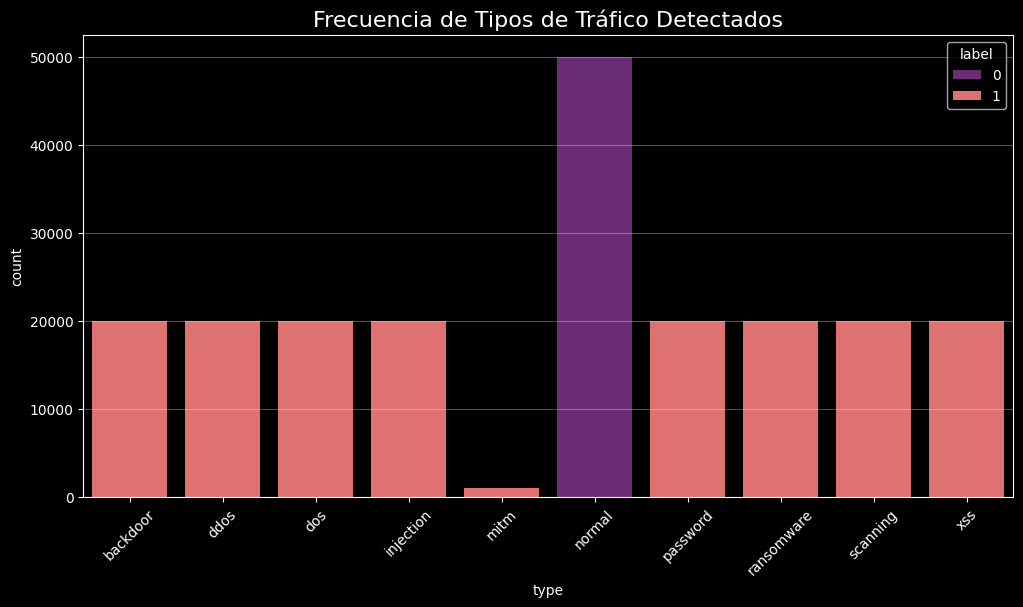

In [27]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='type', hue='label', palette='magma')
plt.title('Frecuencia de Tipos de Tráfico Detectados', fontsize=16)
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

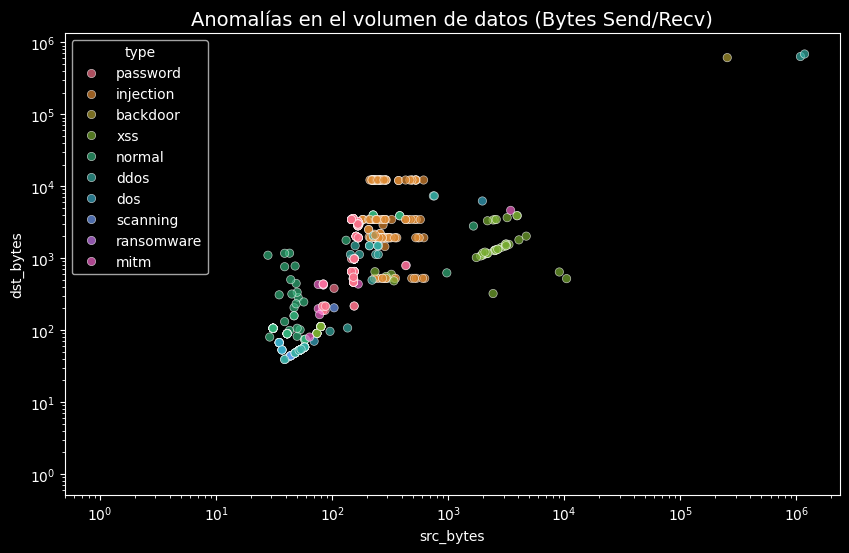

In [28]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df.sample(2000), x='src_bytes', y='dst_bytes', hue='type', alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Anomalías en el volumen de datos (Bytes Send/Recv)', fontsize=14)
plt.show()

In [29]:
proto_dist = pd.crosstab(df['type'], df['proto'], normalize='index') * 100

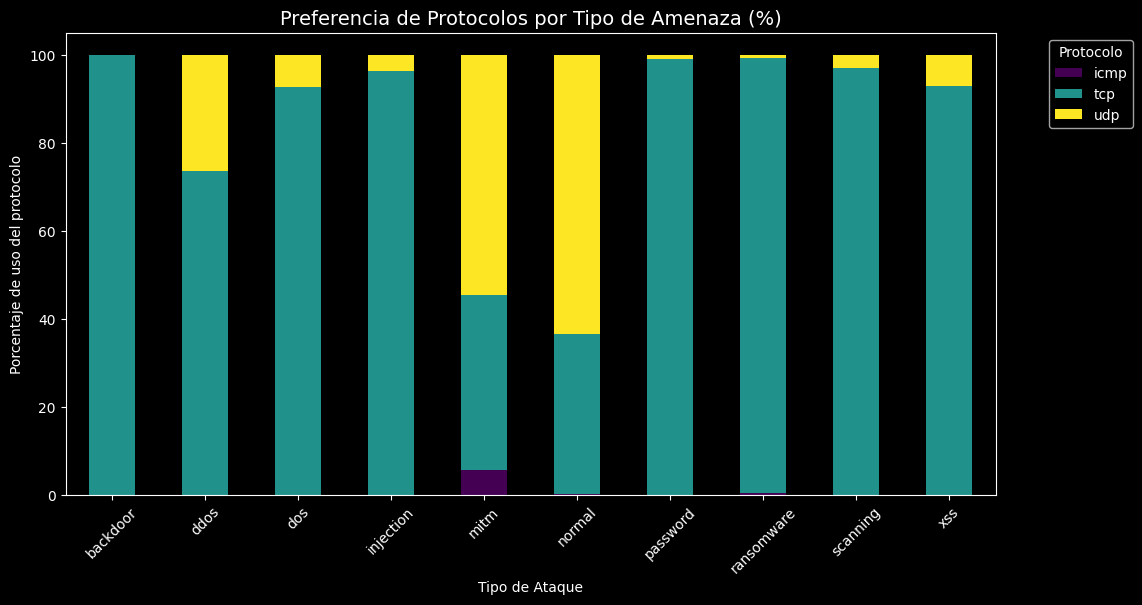

In [30]:
proto_dist.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='viridis')
plt.title('Preferencia de Protocolos por Tipo de Amenaza (%)', fontsize=14)
plt.ylabel('Porcentaje de uso del protocolo')
plt.xlabel('Tipo de Ataque')
plt.legend(title='Protocolo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.show()

In [31]:
print("Top 3 ataques que más usan UDP:")
print(df[df['proto'] == 'udp']['type'].value_counts().head(3))

Top 3 ataques que más usan UDP:
type
normal    31673
ddos       5270
dos        1480
Name: count, dtype: int64


In [32]:
df_ransom = df[df['type'].isin(['ransomware', 'normal'])]

C:\Users\diego\AppData\Local\Temp\ipykernel_18424\2612324282.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ransom, x='type', y='src_bytes', palette='Reds')


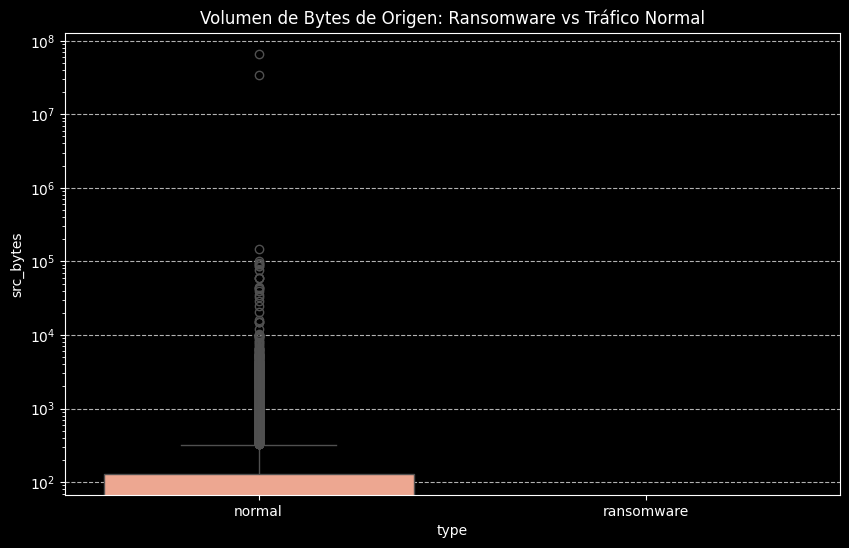

In [33]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_ransom, x='type', y='src_bytes', palette='Reds')
plt.yscale('log')
plt.title('Volumen de Bytes de Origen: Ransomware vs Tráfico Normal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [34]:
ransom_states = df[df['type'] == 'ransomware']['conn_state'].value_counts()

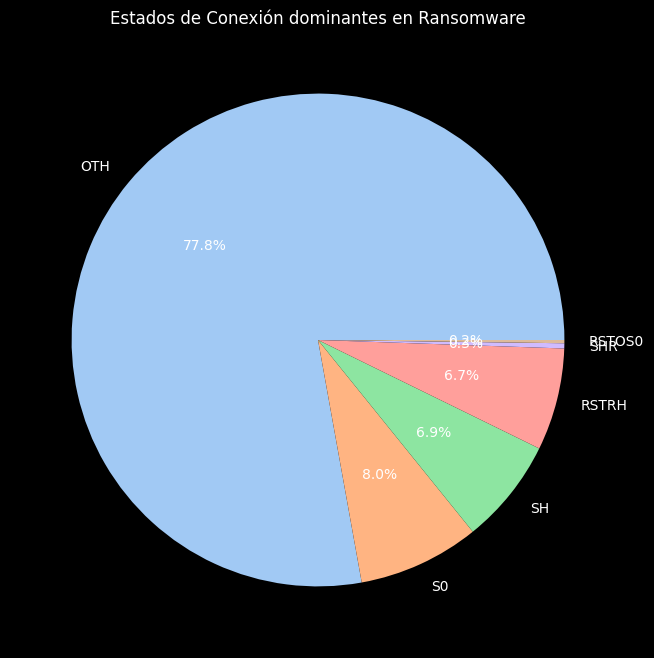

In [35]:
plt.figure(figsize=(8, 8))
plt.pie(ransom_states, labels=ransom_states.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'))
plt.title('Estados de Conexión dominantes en Ransomware')
plt.show()